In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

BASE_PATH = "/kaggle/input/competitions/global-wheat-detection"

In [15]:
df = pd.read_csv(f"{BASE_PATH}/train.csv")

# bbox 문자열 → 숫자 변환
df['bbox'] = df['bbox'].apply(lambda x: np.array(x[1:-1].split(','), dtype=float))

df[['x', 'y', 'w', 'h']] = pd.DataFrame(df['bbox'].tolist(), index=df.index)

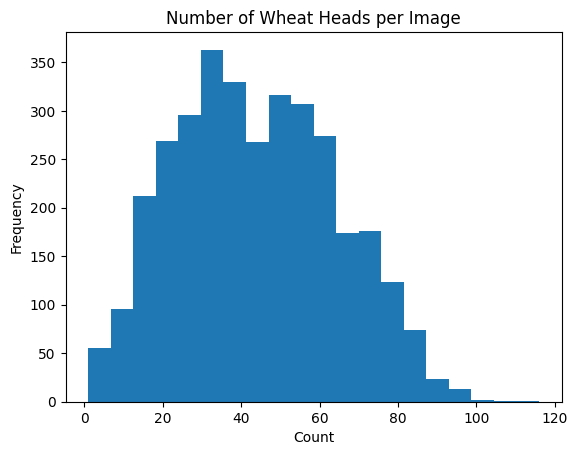

In [16]:
bbox_count = df.groupby('image_id').size()

plt.hist(bbox_count, bins=20)
plt.title("Number of Wheat Heads per Image")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.show()

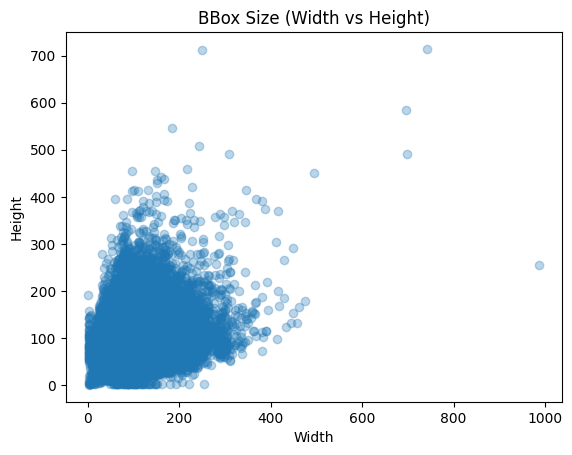

In [17]:
plt.scatter(df['w'], df['h'], alpha=0.3)
plt.title("BBox Size (Width vs Height)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

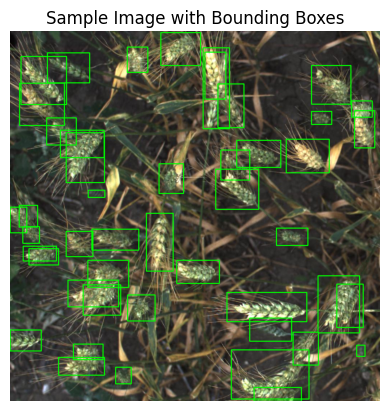

In [18]:
sample_id = df['image_id'].iloc[0]

img = cv2.imread(f"{BASE_PATH}/train/{sample_id}.jpg")

rows = df[df['image_id'] == sample_id]

for _, row in rows.iterrows():
    x, y, w, h = map(int, [row['x'], row['y'], row['w'], row['h']])
    cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Sample Image with Bounding Boxes")
plt.axis('off')

In [19]:
# 1. 라이브러리
import os, shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

BASE_PATH = "/kaggle/input/competitions/global-wheat-detection"
WORK_PATH = "/kaggle/working/wheat_yolo"

In [20]:
# 2. 데이터 로드 + bbox 파싱
df = pd.read_csv(f"{BASE_PATH}/train.csv")

df["bbox"] = df["bbox"].apply(lambda x: np.array(x[1:-1].split(","), dtype=float))
df[["x", "y", "w", "h"]] = pd.DataFrame(df["bbox"].tolist(), index=df.index)

image_ids = df["image_id"].unique()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

In [21]:
# 3. YOLO 폴더 생성
for split in ["train", "val"]:
    os.makedirs(f"{WORK_PATH}/images/{split}", exist_ok=True)
    os.makedirs(f"{WORK_PATH}/labels/{split}", exist_ok=True)

In [22]:
# 4. YOLO 형식으로 변환
def make_yolo_data(ids, split):
    for img_id in ids:
        shutil.copy(
            f"{BASE_PATH}/train/{img_id}.jpg",
            f"{WORK_PATH}/images/{split}/{img_id}.jpg"
        )
        
        rows = df[df["image_id"] == img_id]
        
        with open(f"{WORK_PATH}/labels/{split}/{img_id}.txt", "w") as f:
            for _, row in rows.iterrows():
                x, y, w, h = row["x"], row["y"], row["w"], row["h"]
                img_w, img_h = row["width"], row["height"]
                
                x_center = (x + w / 2) / img_w
                y_center = (y + h / 2) / img_h
                w = w / img_w
                h = h / img_h
                
                f.write(f"0 {x_center} {y_center} {w} {h}\n")

make_yolo_data(train_ids, "train")
make_yolo_data(val_ids, "val")

In [23]:
# 5. data.yaml 생성
yaml_text = f"""
train: {WORK_PATH}/images/train
val: {WORK_PATH}/images/val

nc: 1
names: ['wheat']
"""

with open(f"{WORK_PATH}/data.yaml", "w") as f:
    f.write(yaml_text)

In [24]:
# 6. YOLOv5 설치
%cd /kaggle/working

!git clone https://github.com/ultralytics/yolov5
%cd yolov5

!pip install -r requirements.txt

/kaggle/working
fatal: destination path 'yolov5' already exists and is not an empty directory.
/kaggle/working/yolov5


In [25]:
# 7. 학습 + validation mAP 확인
!python train.py \
--img 640 \
--batch 16 \
--epochs 10 \
--data /kaggle/working/wheat_yolo/data.yaml \
--weights yolov5s.pt \
--name wheat_baseline

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-29 09:26:06.741027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777454766.765680    1939 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777454766.773724    1939 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777454766.794493    1939 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777454766.794520    1939 computation_placer.cc:177] computation placer already registere